# Poisson Latent-Factor Counterfactual Recovery

This notebook simulates a count panel with treatment selection on latent unit factors. The untreated outcome surface is low rank on the log-mean scale, and treatment shifts the treated units' log intensity after adoption.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display

for root in [Path.cwd(), Path.cwd().parent]:
    if (root / "torchonometrics").exists():
        sys.path.insert(0, str(root))
        break

from torchonometrics import LatentFactorGLM

torch.set_default_dtype(torch.float64)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

cuda_available = torch.cuda.is_available()
fit_device = "cpu"
print({
    "torch_version": torch.__version__,
    "cuda_available": cuda_available,
    "fit_device": fit_device,
})


{'torch_version': '2.9.1+cu128', 'cuda_available': True, 'fit_device': 'cpu'}


In [2]:
def simulate_poisson_panel(
    seed: int = 20260329,
    n_units: int = 100,
    n_times: int = 32,
    treatment_start: int = 20,
    share_treated: float = 0.25,
    rank_true: int = 1,
) -> dict[str, torch.Tensor]:
    torch.manual_seed(seed)

    grid = torch.arange(n_times, dtype=torch.float64)
    smooth_rise = 1.55 * torch.sigmoid((grid - 14.0) / 3.2) - 0.70
    drift = 0.35 * (grid / (n_times - 1)) - 0.15
    time_factors = (smooth_rise + drift).reshape(-1, 1)[:, :rank_true]
    unit_factors = torch.randn(n_units, rank_true, dtype=torch.float64)

    selection_score = unit_factors[:, 0] + 0.10 * torch.randn(n_units, dtype=torch.float64)
    threshold = torch.quantile(selection_score, 1.0 - share_treated)
    treated = selection_score >= threshold
    post = torch.arange(n_times) >= treatment_start

    offset = 0.02 * torch.randn(n_units, n_times, dtype=torch.float64)
    eta0 = -0.25 + unit_factors @ time_factors.T + offset
    log_treatment_effect = torch.zeros(n_times, dtype=torch.float64)
    log_treatment_effect[post] = 0.45 + 0.15 * torch.linspace(
        0.0,
        1.0,
        int(post.sum()),
        dtype=torch.float64,
    )

    eta1 = eta0 + treated[:, None] * log_treatment_effect[None, :]
    mu0 = torch.exp(torch.clamp(eta0, min=-2.8, max=1.8))
    mu1 = torch.exp(torch.clamp(eta1, min=-2.8, max=2.1))
    y = torch.poisson(mu1)
    x = torch.ones((n_units, n_times, 1), dtype=torch.float64)

    untreated_mask = (~treated[:, None]) | (~post[None, :])
    validation_draw = torch.rand(n_units, n_times, dtype=torch.float64)
    validation_mask = untreated_mask & (validation_draw < 0.10)
    train_mask = untreated_mask & (~validation_mask)

    return {
        "X": x,
        "Y": y,
        "mu0": mu0,
        "mu1": mu1,
        "treated": treated,
        "post": post,
        "unit_factors": unit_factors,
        "selection_score": selection_score,
        "offset": offset,
        "untreated_mask": untreated_mask,
        "train_mask": train_mask,
        "validation_mask": validation_mask,
        "rank_true": rank_true,
        "treatment_start": treatment_start,
    }


data = simulate_poisson_panel()

design_table = pd.DataFrame(
    [
        ("Units", int(data["X"].shape[0])),
        ("Periods", int(data["X"].shape[1])),
        ("Treatment start", int(data["treatment_start"])),
        ("True rank", int(data["rank_true"])),
        ("Mean count", float(data["Y"].mean())),
        ("Treated units", int(data["treated"].sum())),
        ("Untreated training cells", int(data["train_mask"].sum())),
        ("Untreated validation cells", int(data["validation_mask"].sum())),
    ],
    columns=["Quantity", "Value"],
)

selection_table = pd.DataFrame(
    {
        "group": ["control", "treated"],
        "mean_factor_1": [
            data["unit_factors"][~data["treated"], 0].mean().item(),
            data["unit_factors"][data["treated"], 0].mean().item(),
        ],
        "mean_selection_score": [
            data["selection_score"][~data["treated"]].mean().item(),
            data["selection_score"][data["treated"]].mean().item(),
        ],
    }
)

display(design_table)
display(selection_table.round(3))


,Quantity,Value
0,Units,100.00000
1,Periods,32.00000
2,Treatment start,20.00000
3,True rank,1.00000
4,Mean count,1.11375
5,Treated units,25.00000
6,Untreated training cells,2609.00000
7,Untreated validation cells,291.00000


,group,mean_factor_1,mean_selection_score
0,control,-0.655,-0.670
1,treated,1.027,1.043


## Rank Selection and ATT Recovery

Here we fit **both** a Poisson and a Gaussian latent-factor model to the same count DGP. That makes it possible to separate two questions:

1. does a low-rank latent-factor restriction help at all?
2. conditional on using a latent-factor model, does the Poisson link beat a Gaussian approximation on count data?


In [3]:
def fit_poisson(rank: int, mask: torch.Tensor) -> LatentFactorGLM:
    model = LatentFactorGLM(
        family="poisson",
        rank=rank,
        penalty=2e-1,
        beta_penalty=1e-4,
        optimizer=torch.optim.AdamW,
        optimizer_kwargs={"lr": 0.01, "weight_decay": 0.0},
        maxiter=3200,
        tol=1e-8,
        device=fit_device,
    )
    model.fit(X=data["X"], y=data["Y"], mask=mask, offset=data["offset"])
    return model


def fit_gaussian(rank: int, mask: torch.Tensor) -> LatentFactorGLM:
    model = LatentFactorGLM(
        family="gaussian",
        rank=rank,
        penalty=1e-3,
        beta_penalty=1e-4,
        optimizer=torch.optim.AdamW,
        optimizer_kwargs={"lr": 0.05, "weight_decay": 0.0},
        maxiter=2200,
        tol=1e-8,
        device=fit_device,
    )
    model.fit(X=data["X"], y=data["Y"], mask=mask, offset=data["offset"])
    return model


candidate_ranks = [0, 1, 2, 3]
poisson_rows = []
gaussian_rows = []

for rank in candidate_ranks:
    poisson_model = fit_poisson(rank=rank, mask=data["train_mask"])
    validation_index = poisson_model.predict_index(data["X"], offset=data["offset"])
    poisson_loss = F.poisson_nll_loss(
        validation_index[data["validation_mask"]],
        data["Y"][data["validation_mask"]],
        log_input=True,
        full=False,
        reduction="mean",
    ).item()
    poisson_rows.append(
        {
            "rank": rank,
            "validation_poisson_nll": poisson_loss,
            "poisson_iterations": poisson_model.iterations_run,
        }
    )

    gaussian_model = fit_gaussian(rank=rank, mask=data["train_mask"])
    gaussian_mean = gaussian_model.predict_mean(data["X"], offset=data["offset"])
    gaussian_loss = torch.mean(
        (gaussian_mean[data["validation_mask"]] - data["Y"][data["validation_mask"]]) ** 2
    ).item()
    gaussian_rows.append(
        {
            "rank": rank,
            "validation_gaussian_mse": gaussian_loss,
            "gaussian_iterations": gaussian_model.iterations_run,
        }
    )

poisson_rank_table = pd.DataFrame(poisson_rows).sort_values("rank")
gaussian_rank_table = pd.DataFrame(gaussian_rows).sort_values("rank")
best_rank_poisson = int(
    poisson_rank_table.loc[poisson_rank_table["validation_poisson_nll"].idxmin(), "rank"]
)
best_rank_gaussian = int(
    gaussian_rank_table.loc[gaussian_rank_table["validation_gaussian_mse"].idxmin(), "rank"]
)

poisson_model = fit_poisson(rank=best_rank_poisson, mask=data["untreated_mask"])
gaussian_model = fit_gaussian(rank=best_rank_gaussian, mask=data["untreated_mask"])
mu0_hat_poisson = poisson_model.predict_mean(data["X"], offset=data["offset"])
mu0_hat_gaussian = gaussian_model.predict_mean(data["X"], offset=data["offset"])

treated_post_mask = data["treated"][:, None] & data["post"][None, :]
true_att = (data["mu1"][treated_post_mask] - data["mu0"][treated_post_mask]).mean().item()
poisson_att = (data["Y"][treated_post_mask] - mu0_hat_poisson[treated_post_mask]).mean().item()
gaussian_att = (data["Y"][treated_post_mask] - mu0_hat_gaussian[treated_post_mask]).mean().item()
did_att = (
    data["Y"][data["treated"]][:, data["post"]].mean()
    - data["Y"][data["treated"]][:, ~data["post"]].mean()
    - (
        data["Y"][~data["treated"]][:, data["post"]].mean()
        - data["Y"][~data["treated"]][:, ~data["post"]].mean()
    )
).item()

att_summary = pd.DataFrame(
    [
        {"estimator": "True ATT", "estimate": true_att, "bias": 0.0},
        {
            "estimator": "Poisson latent-factor ATT",
            "estimate": poisson_att,
            "bias": poisson_att - true_att,
        },
        {
            "estimator": "Gaussian latent-factor ATT",
            "estimate": gaussian_att,
            "bias": gaussian_att - true_att,
        },
        {
            "estimator": "Two-group DiD",
            "estimate": did_att,
            "bias": did_att - true_att,
        },
    ]
)

rank_comparison = poisson_rank_table.merge(gaussian_rank_table, on="rank")
display(rank_comparison.round(6))
display(att_summary.round(3))


,rank,validation_poisson_nll,poisson_iterations,validation_gaussian_mse,gaussian_iterations
0,0,0.985319,157,1.281424,53
1,1,0.870603,159,0.982472,342
2,2,0.886951,336,1.092926,447
3,3,0.925217,336,1.246513,414


,estimator,estimate,bias
0,True ATT,1.489,0.000
1,Poisson latent-factor ATT,2.635,1.145
2,Gaussian latent-factor ATT,2.731,1.241
3,Two-group DiD,3.463,1.974


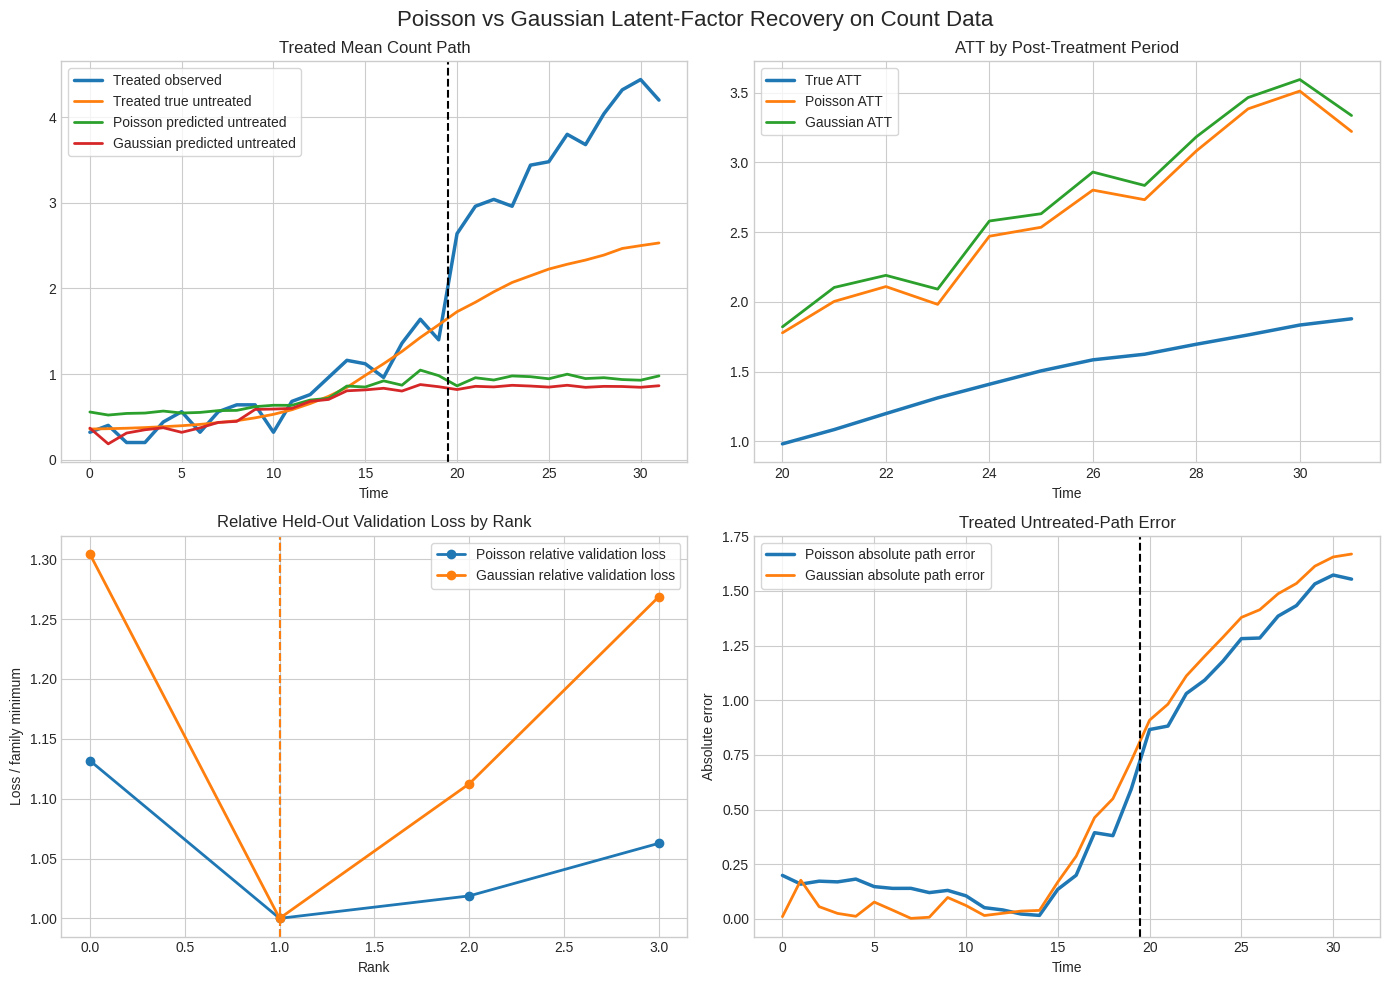

In [4]:
time_index = torch.arange(data["X"].shape[1]).cpu().numpy()
post_index = torch.arange(data["X"].shape[1])[data["post"]].cpu().numpy()
treatment_line = data["treatment_start"] - 0.5

treated_observed_path = data["Y"][data["treated"]].mean(dim=0).detach().cpu().numpy()
treated_true_untreated_path = data["mu0"][data["treated"]].mean(dim=0).detach().cpu().numpy()
treated_predicted_poisson_path = mu0_hat_poisson[data["treated"]].mean(dim=0).detach().cpu().numpy()
treated_predicted_gaussian_path = mu0_hat_gaussian[data["treated"]].mean(dim=0).detach().cpu().numpy()
estimated_att_poisson_by_time = (
    data["Y"][data["treated"]][:, data["post"]]
    - mu0_hat_poisson[data["treated"]][:, data["post"]]
).mean(dim=0).detach().cpu().numpy()
estimated_att_gaussian_by_time = (
    data["Y"][data["treated"]][:, data["post"]]
    - mu0_hat_gaussian[data["treated"]][:, data["post"]]
).mean(dim=0).detach().cpu().numpy()
true_att_by_time = (
    data["mu1"][data["treated"]][:, data["post"]]
    - data["mu0"][data["treated"]][:, data["post"]]
).mean(dim=0).detach().cpu().numpy()
poisson_relative_validation = (
    poisson_rank_table["validation_poisson_nll"] / poisson_rank_table["validation_poisson_nll"].min()
)
gaussian_relative_validation = (
    gaussian_rank_table["validation_gaussian_mse"] / gaussian_rank_table["validation_gaussian_mse"].min()
)
poisson_path_error = abs(treated_predicted_poisson_path - treated_true_untreated_path)
gaussian_path_error = abs(treated_predicted_gaussian_path - treated_true_untreated_path)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(time_index, treated_observed_path, label="Treated observed", linewidth=2.5)
axes[0, 0].plot(time_index, treated_true_untreated_path, label="Treated true untreated", linewidth=2.0)
axes[0, 0].plot(time_index, treated_predicted_poisson_path, label="Poisson predicted untreated", linewidth=2.0)
axes[0, 0].plot(time_index, treated_predicted_gaussian_path, label="Gaussian predicted untreated", linewidth=2.0)
axes[0, 0].axvline(treatment_line, color="black", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Treated Mean Count Path")
axes[0, 0].set_xlabel("Time")
axes[0, 0].legend(frameon=True)

axes[0, 1].plot(post_index, true_att_by_time, label="True ATT", linewidth=2.5)
axes[0, 1].plot(post_index, estimated_att_poisson_by_time, label="Poisson ATT", linewidth=2.0)
axes[0, 1].plot(post_index, estimated_att_gaussian_by_time, label="Gaussian ATT", linewidth=2.0)
axes[0, 1].set_title("ATT by Post-Treatment Period")
axes[0, 1].set_xlabel("Time")
axes[0, 1].legend(frameon=True)

axes[1, 0].plot(poisson_rank_table["rank"], poisson_relative_validation, marker="o", linewidth=2.0, label="Poisson relative validation loss")
axes[1, 0].plot(gaussian_rank_table["rank"], gaussian_relative_validation, marker="o", linewidth=2.0, label="Gaussian relative validation loss")
axes[1, 0].axvline(best_rank_poisson, color="tab:blue", linestyle="--", linewidth=1.5)
axes[1, 0].axvline(best_rank_gaussian, color="tab:orange", linestyle="--", linewidth=1.5)
axes[1, 0].set_title("Relative Held-Out Validation Loss by Rank")
axes[1, 0].set_xlabel("Rank")
axes[1, 0].set_ylabel("Loss / family minimum")
axes[1, 0].legend(frameon=True)

axes[1, 1].plot(time_index, poisson_path_error, label="Poisson absolute path error", linewidth=2.5)
axes[1, 1].plot(time_index, gaussian_path_error, label="Gaussian absolute path error", linewidth=2.0)
axes[1, 1].axvline(treatment_line, color="black", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Treated Untreated-Path Error")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Absolute error")
axes[1, 1].legend(frameon=True)

fig.suptitle("Poisson vs Gaussian Latent-Factor Recovery on Count Data", fontsize=16)
fig.tight_layout()
plt.show()


## Takeaway

On this Poisson DGP, the Poisson latent-factor fit is only modestly better than the Gaussian latent-factor fit, and both overestimate the ATT. So the link function is not the full story here: using the Poisson mean restriction helps a bit, but it does not by itself eliminate the finite-sample counterfactual error coming from latent-factor estimation under treatment selection.
